<a href="https://colab.research.google.com/github/Douglasdcg/atividade_ativa_ap/blob/main/ATIVIDADE_ATIVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atividade ativa
Nome: Douglas Conceição da Glória     Matrícula: 2586101550

Com base nos dados de um conjunto de imóveis localizados na cidade de Ames, Iowa (EUA), e considerando as características das propriedades — como quantidade de dormitórios, existência de garagem, lareira, piscina, entre outros atributos — apresenta-se a seguir uma análise estatística do valor de venda dos imóveis, utilizando o método de Regressão Linear.

In [47]:

# =====================================
# IMPORTAÇÃO DE BIBLIOTECAS
# =====================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("deep")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings("ignore")


Importação e impressão da base de dados "Ames Housing.csv"

In [48]:

# =====================================
# IMPORTAÇÃO DA BASE DE DADOS
# =====================================

data = pd.read_csv("Data/AmesHousing.csv")

print("Visualização inicial da base:")
display(data.head())

print(f"\nDimensão da base: {data.shape[0]} linhas e {data.shape[1]} colunas")


Visualização inicial da base:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900



Dimensão da base: 2930 linhas e 82 colunas


In [ ]:
display(data)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


Analise Exploratória de Dados:

Na etapa de análise exploratória, são calculadas estatísticas descritivas da variável SalePrice, que representa o preço de venda dos imóveis. Essas estatísticas fornecem informações como média, mediana, valores mínimos e máximos, além da dispersão dos preços. Em seguida, é construído um histograma para visualizar a distribuição do preço de venda, permitindo identificar a assimetria da distribuição e a presença de imóveis de alto valor.

,Valor
count,"2,930.00"
mean,"180,796.06"
std,"79,886.69"
min,"12,789.00"
25%,"129,500.00"
50%,"160,000.00"
75%,"213,500.00"
max,"755,000.00"


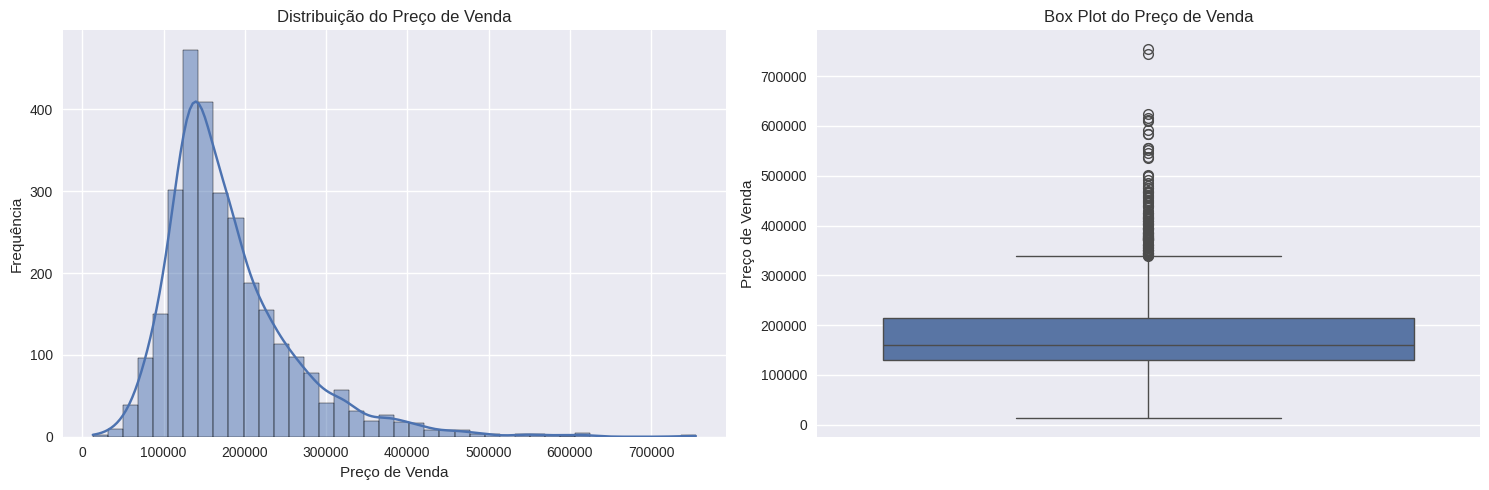


--- Análise de Correlação ---

Top 10 Características Numéricas mais correlacionadas com SalePrice:
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


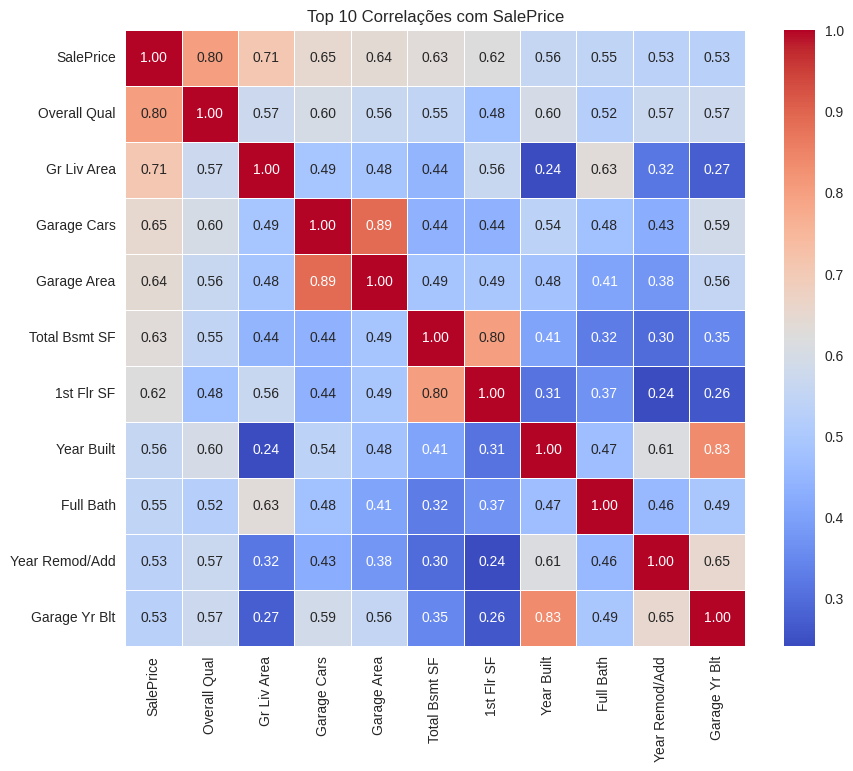


--- Análise de SalePrice por Qualidade Geral ---



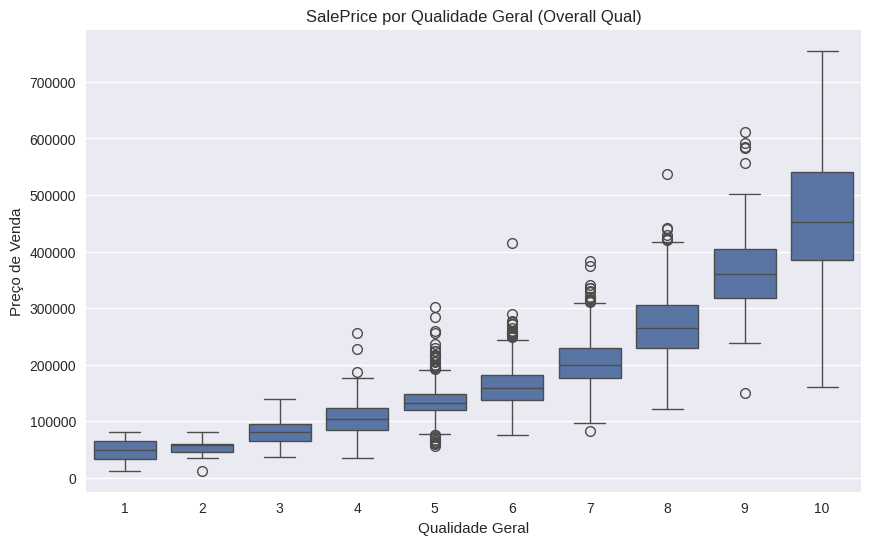

Esta análise expandida fornece estatísticas adicionais e visualizações para uma compreensão mais completa do impacto das variáveis no preço de venda.


In [ ]:
# =====================================
# ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# =====================================

# Estatísticas descritivas do preço
desc_price = data['SalePrice'].describe().to_frame(name="Valor")

display(
    desc_price.style
    .format("{:,.2f}")
    .set_caption("Estatísticas Descritivas do Preço de Venda")
)

# Distribuição do preço (Histograma e Box Plot)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['SalePrice'], bins=40, kde=True)
plt.xlabel("Preço de Venda")
plt.ylabel("Frequência")
plt.title("Distribuição do Preço de Venda")

plt.subplot(1, 2, 2)
sns.boxplot(y=data['SalePrice'])
plt.ylabel("Preço de Venda")
plt.title("Box Plot do Preço de Venda")

plt.tight_layout()
plt.show()

print("\n--- Análise de Correlação ---\n")

# Correlação com características numéricas
numeric_cols = data.select_dtypes(include=np.number).columns
correlation_matrix = data[numeric_cols].corr()
sale_price_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)

print("Top 10 Características Numéricas mais correlacionadas com SalePrice:")
print(sale_price_corr.head(11)) # Inclui SalePrice em si

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix.loc[sale_price_corr.head(11).index, sale_price_corr.head(11).index],
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Top 10 Correlações com SalePrice')
plt.show()

print("\n--- Análise de SalePrice por Qualidade Geral ---\n")

# Correlação com característica categórica chave (Ex: Qualidade Geral)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Overall Qual', y='SalePrice', data=data)
plt.title('SalePrice por Qualidade Geral (Overall Qual)')
plt.xlabel('Qualidade Geral')
plt.ylabel('Preço de Venda')
plt.show()

print("Esta análise expandida fornece estatísticas adicionais e visualizações para uma compreensão mais completa do impacto das variáveis no preço de venda.")

Seleção das variáveis do modelo

Para a construção do modelo de regressão linear, foram selecionadas quatro variáveis independentes com forte relação econômica e estatística com o preço de venda:

Gr Liv Area: área construída acima do solo;
Overall Qual: qualidade geral do imóvel;
Garage Cars: número de vagas na garagem;
Total Bsmt SF: área total do porão.

A variável SalePrice é definida como variável dependente. Antes da modelagem, é realizada uma verificação de valores ausentes nas variáveis selecionadas. As observações contendo dados faltantes são removidas, garantindo a consistência e a confiabilidade do modelo estatístico.

,Valores Ausentes
Gr Liv Area,0
Overall Qual,0
Garage Cars,1
Total Bsmt SF,1



Dimensão da base após remover valores ausentes: 2928 linhas e 5 colunas

--- Estatísticas Descritivas das Variáveis Selecionadas --- (após tratamento de ausentes)



,Gr Liv Area,Overall Qual,Garage Cars,Total Bsmt SF
count,"2,928.00","2,928.00","2,928.00","2,928.00"
mean,"1,499.78",6.10,1.77,"1,051.68"
std,505.52,1.41,0.76,440.68
min,334.00,1.00,0.00,0.00
25%,"1,126.00",5.00,1.00,793.00
50%,"1,442.00",6.00,2.00,990.00
75%,"1,742.25",7.00,2.00,"1,302.00"
max,"5,642.00",10.00,5.00,"6,110.00"


,SalePrice
count,"2,928.00"
mean,"180,841.03"
std,"79,889.90"
min,"12,789.00"
25%,"129,500.00"
50%,"160,000.00"
75%,"213,500.00"
max,"755,000.00"



--- Visualização das Relações entre Variáveis --- (Pairplots)



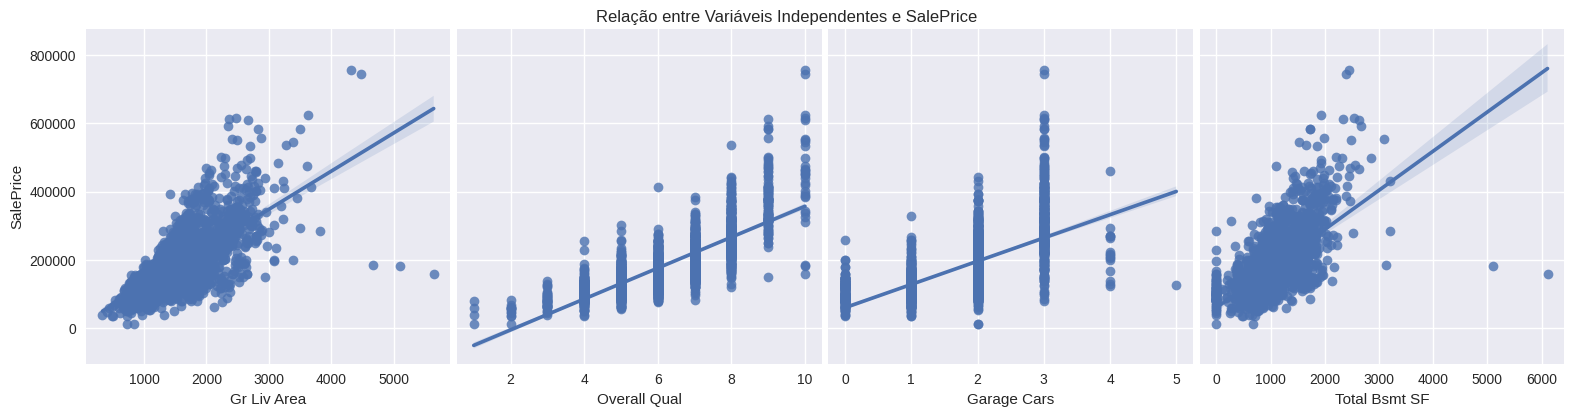


--- Correlação entre as Variáveis Independentes --- (para verificar multicolinearidade)



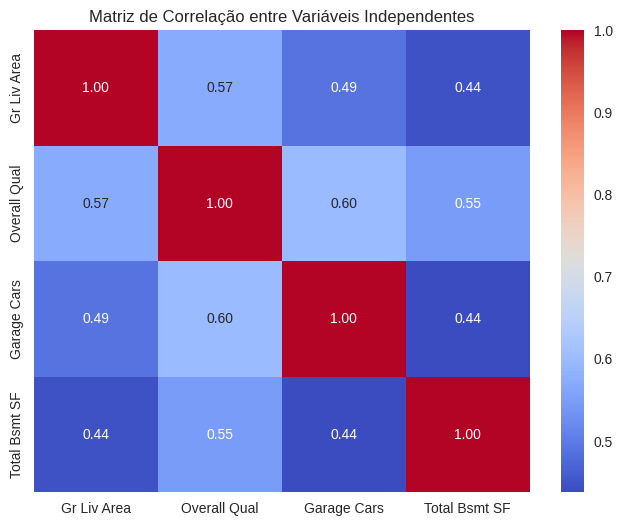

Esta análise adicional detalha a composição da base de dados após o pré-processamento e as relações entre as variáveis escolhidas.


In [ ]:

# =================================
# SELEÇÃO DAS VARIÁVEIS DO MODELO
# =================================

X = data[
    ['Gr Liv Area',
     'Overall Qual',
     'Garage Cars',
     'Total Bsmt SF']
]

y = data['SalePrice']

# Verificação de valores ausentes
missing = X.isnull().sum().to_frame(name="Valores Ausentes")

display(
    missing.style
    .background_gradient(cmap="Reds")
    .set_caption("Valores Ausentes por Variável")
)

# Remoção de valores ausentes
base_modelo = pd.concat([X, y], axis=1).dropna()

X = base_modelo[X.columns]
y = base_modelo['SalePrice']

print(f"\nDimensão da base após remover valores ausentes: {base_modelo.shape[0]} linhas e {base_modelo.shape[1]} colunas")

print("\n--- Estatísticas Descritivas das Variáveis Selecionadas --- (após tratamento de ausentes)\n")
display(X.describe().style.format("{:,.2f}").set_caption("Estatísticas Descritivas das Variáveis Independentes (X)"))
display(y.describe().to_frame(name="SalePrice").style.format("{:,.2f}").set_caption("Estatísticas Descritivas da Variável Dependente (y)"))

print("\n--- Visualização das Relações entre Variáveis --- (Pairplots)\n")
sns.pairplot(base_modelo, y_vars=['SalePrice'], x_vars=['Gr Liv Area', 'Overall Qual', 'Garage Cars', 'Total Bsmt SF'], kind='reg', height=4)
plt.suptitle('Relação entre Variáveis Independentes e SalePrice', y=1.02) # Ajusta o título para não sobrepor
plt.show()

print("\n--- Correlação entre as Variáveis Independentes --- (para verificar multicolinearidade)\n")
corr_X = X.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_X, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Variáveis Independentes')
plt.show()

print("Esta análise adicional detalha a composição da base de dados após o pré-processamento e as relações entre as variáveis escolhidas.")

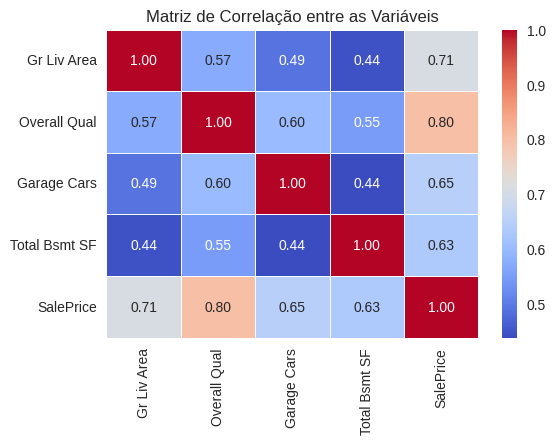

,Variável,Coeficiente
1,Overall Qual,"R$ 23,652.66"
2,Garage Cars,"R$ 17,446.60"
0,Gr Liv Area,R$ 45.12
3,Total Bsmt SF,R$ 34.46


,Métrica,Valor
0,R²,0.7895
1,RMSE,39359.2612


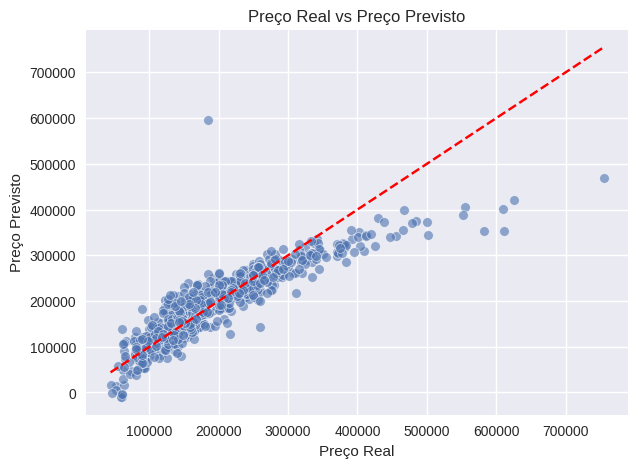

In [ ]:

# =====================
# MATRIZ DE CORRELAÇÃO
# =====================

plt.figure(figsize=(6, 4))
sns.heatmap(
    base_modelo.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Matriz de Correlação entre as Variáveis")
plt.show()


# ===================
# DIVISÃO DOS DADOS
# ===================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# =====================================
# AJUSTE DO MODELO DE REGRESSÃO LINEAR
# =====================================

modelo = LinearRegression()
modelo.fit(X_train, y_train)


# =======================
# TABELA DE COEFICIENTES
# =======================

coeficientes = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": modelo.coef_
}).sort_values(by="Coeficiente", ascending=False)

display(
    coeficientes.style
    .format({"Coeficiente": "R$ {:,.2f}"})
    .background_gradient(cmap="Blues")
    .set_caption("Coeficientes do Modelo de Regressão Linear")
)


# ====================
# AVALIAÇÃO DO MODELO
# ====================

y_pred = modelo.predict(X_test)

avaliacao = pd.DataFrame({
    "Métrica": ["R²", "RMSE"],
    "Valor": [
        r2_score(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred))
    ]
})

display(
    avaliacao.style
    .format({"Valor": "{:.4f}"})
    .set_caption("Métricas de Avaliação do Modelo")
)


# ====================================
# GRÁFICO: VALORES REAIS VS PREVISTOS
# ====================================

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")
plt.title("Preço Real vs Preço Previsto")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.show()
